In [1]:
import os
import torch

from tqdm import tqdm
from pathlib import Path
from rich.table import Table
from rich.console import Console

from utils import load_shards, seed_everything, balance_data, filter_data, remap_labels

SEED = 7

BACKBONE = os.environ.get("BACKBONE", "dinov3-vit7b16-pretrain-lvd1689m")
IMAGE_SIZE = os.environ.get("IMAGE_SIZE", 224)

MODEL_TRAIN = Path(f"facebook/{BACKBONE}/bfloat16_normal_{IMAGE_SIZE}/train")
MODEL_VAL = Path(f"facebook/{BACKBONE}/bfloat16_normal_{IMAGE_SIZE}/val")
MODEL_TEST = Path(f"facebook/{BACKBONE}/bfloat16_normal_{IMAGE_SIZE}/test")
ROOT = Path("/home/cavadalab/Documents/scsv/fungitastic2026_2/data_processed")



In [99]:
def prepare_data() -> tuple[dict[str, torch.Tensor | None], dict[str, torch.Tensor | None], dict[str, torch.Tensor | None]]:
    train_data = load_shards(ROOT / MODEL_TRAIN)
    val_data = load_shards(ROOT / MODEL_VAL)
    test_data = load_shards(ROOT / MODEL_TEST)    

    # filtering out classes in train/val not in test
    unique_labels_train = train_data['labels'].unique()
    unique_labels_val = val_data['labels'].unique()
    unique_labels_test = test_data['labels'].unique()

    train_union_val_unique = torch.cat([unique_labels_train, unique_labels_val], dim=0).unique()
    classes_in_train_val_not_in_test = set(train_union_val_unique.tolist()) - set(unique_labels_test.tolist())
    classes_in_train_val_not_in_test_tensor = torch.tensor(list(classes_in_train_val_not_in_test))
    print(f"Number of classes in test set not in train/val: {len(classes_in_train_val_not_in_test)}")

    # filter first
    train_data_filtered = filter_data(train_data, classes_in_train_val_not_in_test_tensor)
    val_data_filtered = filter_data(val_data, classes_in_train_val_not_in_test_tensor)

    # balance then
    samples_per_class = 10
    train_data_balanced = balance_data(train_data_filtered, seed=SEED, samples_per_class=samples_per_class)
    val_data_balanced = balance_data(val_data_filtered, seed=SEED, samples_per_class=samples_per_class)
    # test_data_balanced = balance_data(test_data, seed=SEED, samples_per_class=samples_per_class)

    train_labels, val_labels, test_labels = remap_labels(train_data_balanced['labels'], val_data_balanced['labels'], test_data['labels'])

    return (
        {**train_data_balanced, "labels": train_labels},
        {**val_data_balanced, "labels": val_labels},
        {**test_data, "labels": test_labels},
    )

In [100]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
table = Table(title="One-Shot Classification Results")
table.add_column("Method", justify="left", style="cyan", no_wrap=True)
table.add_column("Accuracy", justify="right", style="magenta")    

train_data, val_data, test_data = prepare_data()

Loading test: 100%|██████████| 20/20 [00:00<00:00, 63.69shard/s]


Number of classes in test set not in train/val: 21


In [106]:
len(test_data['labels'])

9763

In [110]:
train_labels = train_data['labels']
val_labels = val_data['labels']
test_labels = test_data['labels']

train_features = train_data['cls_tokens']
val_features = val_data['cls_tokens']
test_features = test_data['cls_tokens']


# 2. Setup output tensor and indices
num_classes = train_labels.max().item() + 1
out = torch.zeros(num_classes, train_features.size(1), dtype=train_features.dtype, device=train_features.device)

# Expand labels so the shape matches the features tensor: [N, Features]
index = train_labels.to(device=train_features.device, dtype=torch.int64).unsqueeze(1).expand_as(train_features)

# 3. Compute the grouped mean
out.scatter_reduce_(dim=0, index=index, src=train_features, reduce="mean", include_self=False)

print(out.shape)
print(test_labels)

print(test_features.shape)

euclidean_distances = torch.cdist(test_features, out)
predicted_labels = euclidean_distances.argmin(dim=1)
accuracy = (predicted_labels == test_labels).float().mean().item()
print(f"Prototype method accuracy: {accuracy:.4f}")

torch.Size([194, 4096])
tensor([ 81,  69,  69,  ...,  73,  73, 102])
torch.Size([9763, 4096])
Prototype method accuracy: 0.3106


In [102]:
import seaborn as sns

two_dim_matrix = torch.zeros((num_classes, num_classes))

for i,j in zip(test_labels, predicted_labels):
    two_dim_matrix[i, j] += 1

# normalize the matrix by row
two_dim_matrix = two_dim_matrix / two_dim_matrix.sum(dim=1, keepdim=True)


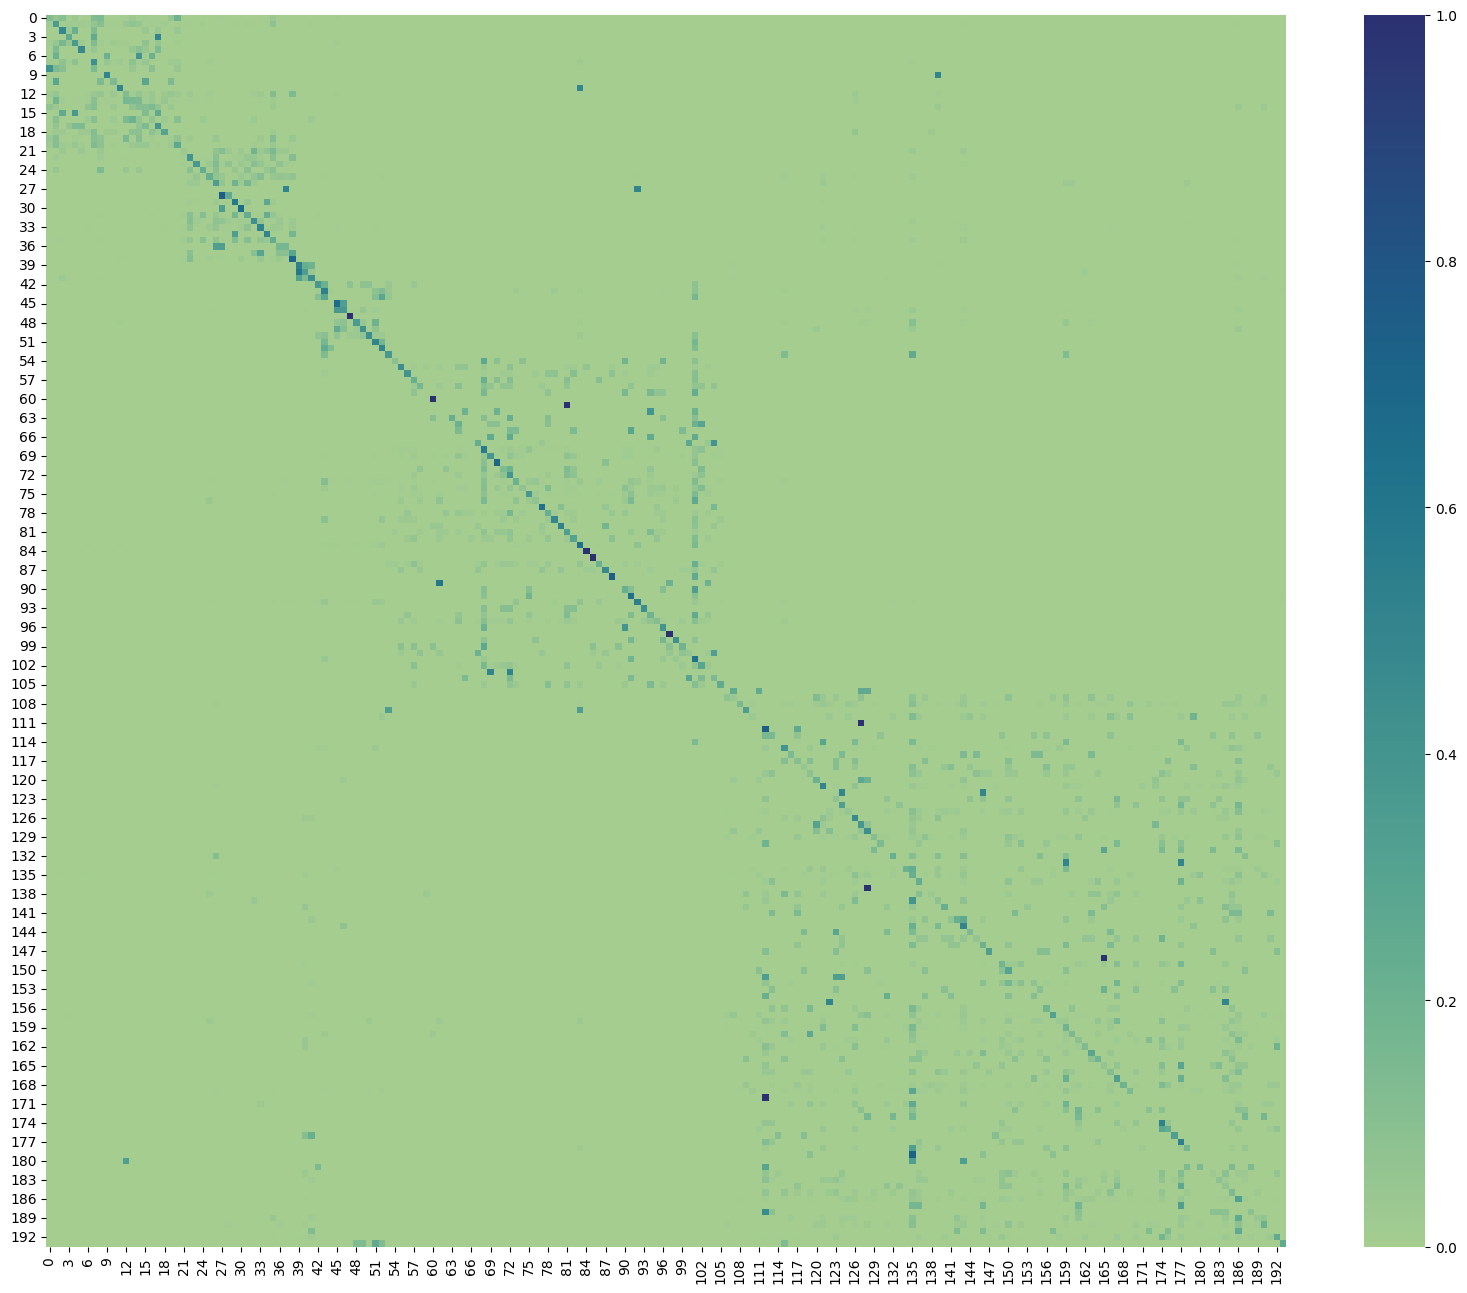

In [103]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Set the figure size (width=10, height=8)
plt.figure(figsize=(20, 16))

# 2. Draw your heatmap
sns.heatmap(two_dim_matrix, cmap="crest")

# 3. Display the plot
plt.show()

In [104]:
import numpy as np
np.trace(two_dim_matrix.cpu().numpy()) / num_classes

0.2586614864388692

In [108]:
a = torch.tensor([[0,1,2], [3,4,5], [6,7,8]])
a

tensor([[0, 1, 2],
        [3, 4, 5],
        [6, 7, 8]])

In [109]:
a[0,2]

tensor(2)